<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/eda%20for%20netflix%20dataset%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Shape of Dataset: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


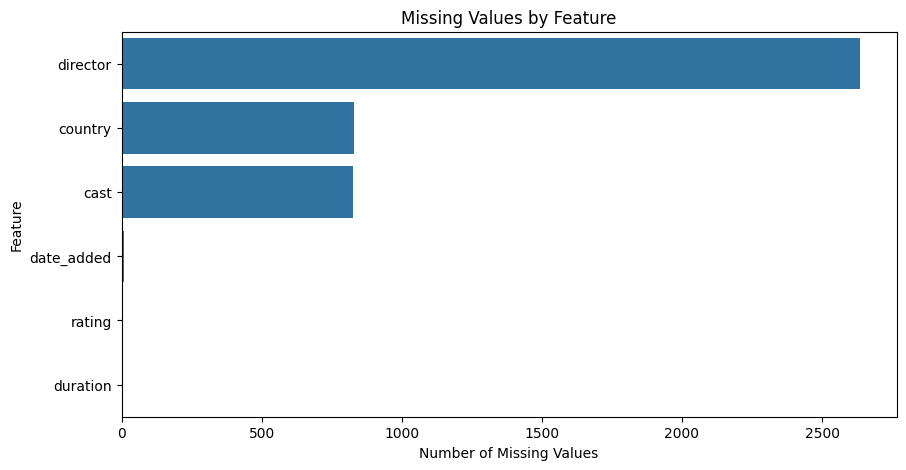

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.values, y=missing.index)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

plt.show()

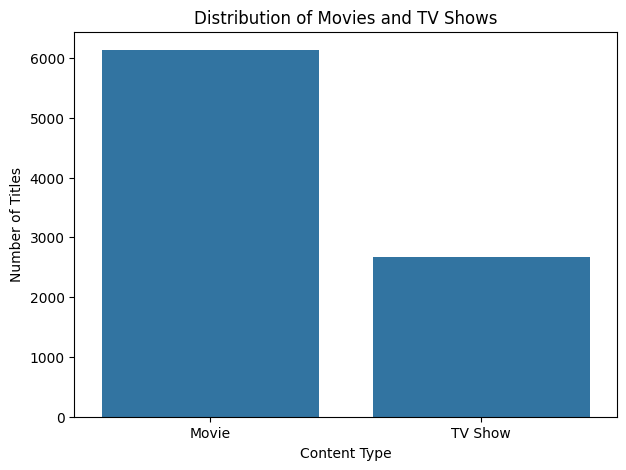

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="type")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

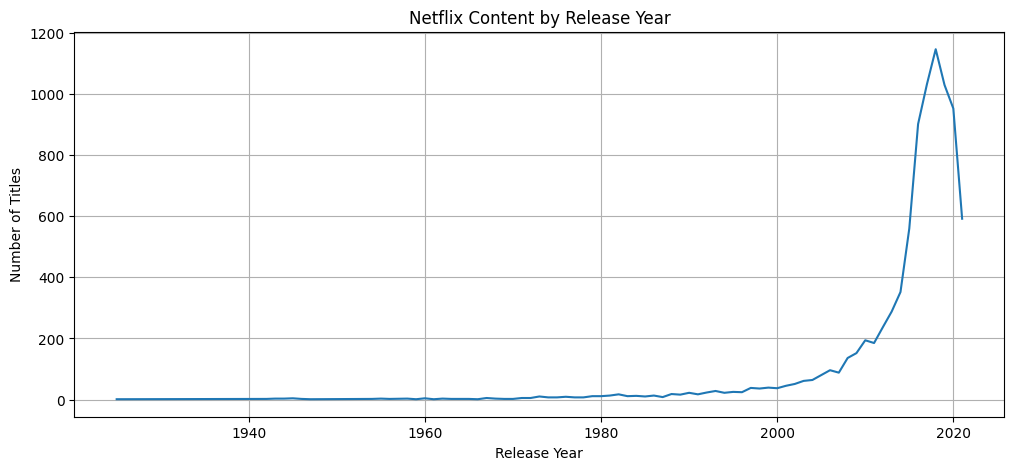

In [ ]:
year_count = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.plot(year_count.index, year_count.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.show()

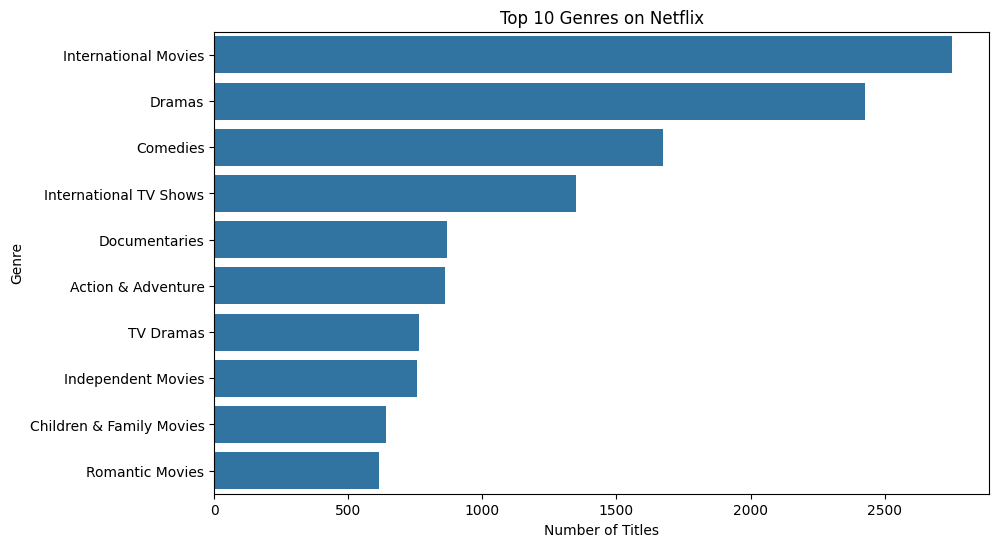

In [ ]:
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

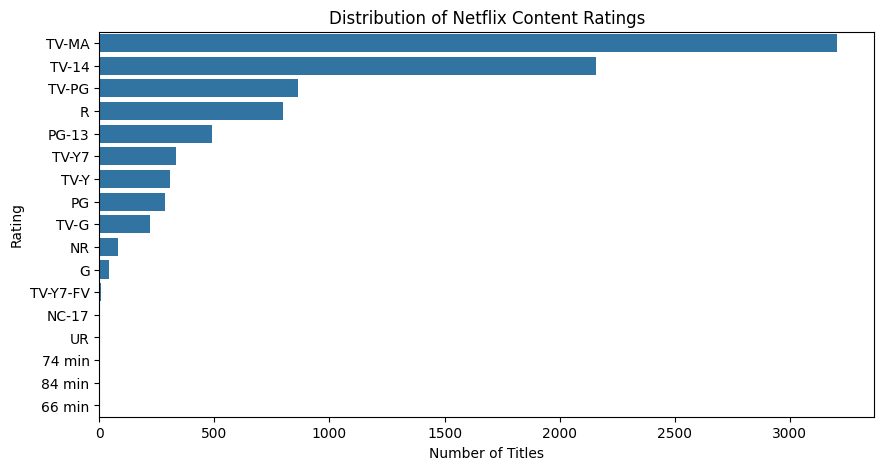

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

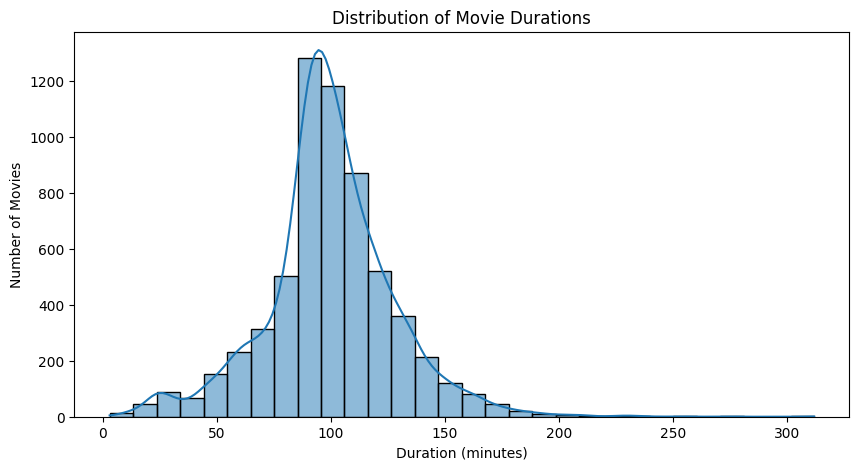

In [ ]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

plt.figure(figsize=(10, 5))

sns.histplot(
    movies["duration_min"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

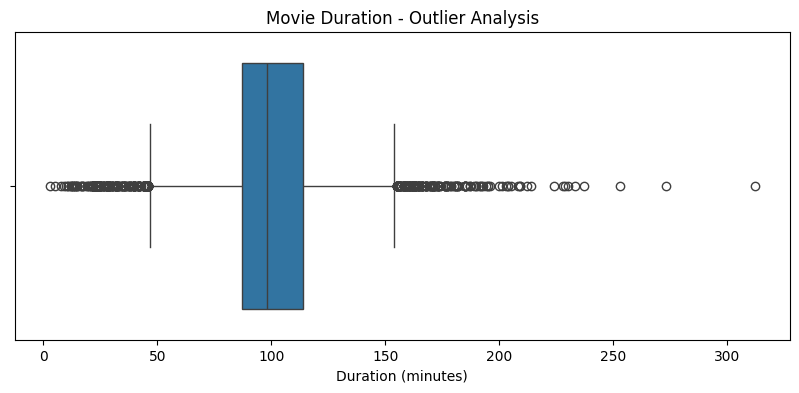

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=movies["duration_min"].dropna()
)

plt.title("Movie Duration - Outlier Analysis")
plt.xlabel("Duration (minutes)")

plt.show()

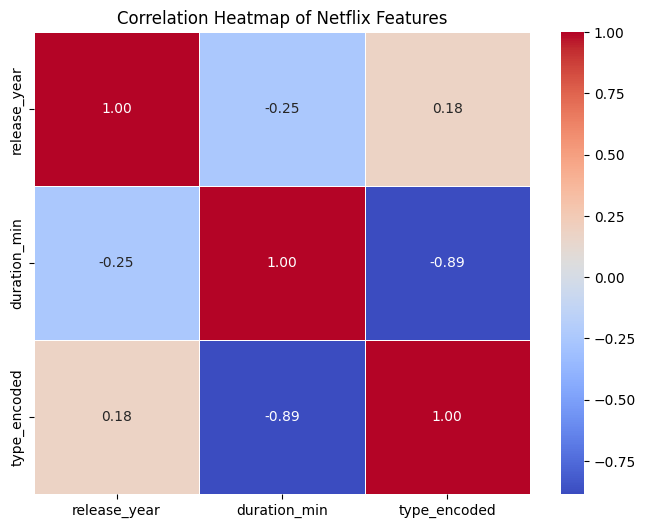

In [ ]:
# ---------------------------------------
# CORRELATION HEATMAP
# ---------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy
corr_df = df.copy()

# Encode content type
corr_df["type_encoded"] = corr_df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

# Extract numerical movie duration
corr_df["duration_min"] = (
    corr_df["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# Select numerical features
numeric_features = [
    "release_year",
    "duration_min",
    "type_encoded"
]

correlation = corr_df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Netflix Features")
plt.show()